In [1]:
import numpy as np
from astropy.io import fits
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.pyplot import cm
import scipy.constants as cst
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.markers as mmarkers
from scipy.interpolate import interp1d
from specutils import Spectrum1D
import astropy.units as u
from specutils.manipulation import FluxConservingResampler
from pybaselines import whittaker
import pickle
import astropy.units as u
from astropy.stats import gaussian_fwhm_to_sigma
from astropy.cosmology import Planck18 as cosmo
from functools import partial

noise_model_SW = pd.read_csv('TIM_SW_loading.tsv', sep='\t')
noise_model_LW = pd.read_csv('TIM_LW_loading.tsv', sep='\t')

In [2]:
freq_CII = 1900.53690000 * u.GHz
freq_CI10 = 492.16 *u.GHz
freq_CI21 = 809.34 * u.GHz
rest_freq_list = [115.27120180  *u.GHz* J_up for J_up in range(1, 9)]
line_list = ["CO({}-{})".format(J_up, J_up - 1) for J_up in range(1, 9)]
fir_lines_list = ['NeII 13$\\rm \\mu m$', 'NeIII 16$\\rm \\mu m$', 
                  'H2 17$\\rm \\mu m$', 'SIII 19$\\rm \\mu m$', 'OIV 26$\\rm \\mu m$',
                   'SIII 33$\\rm \\mu m$', 'SiII 35$\\rm \\mu m$', 'OIII 52$\\rm \\mu m$', 
                   'NIII 57$\\rm \\mu m$', 'OI 63$\\rm \\mu m$', 'OIII 88$\\rm \\mu m$', 'NII 122$\\rm \\mu m$',
                   'OI 145$\\rm \\mu m$','NII 205$\\rm \\mu m$'] #Do not add CII which is dealt with differently!                     
fir_lines_nu =   [23403.00218579, 19279.2577492 , 17603.7849677 , 16023.11373597, 11579.46921591,  8954.37449223,  8609.77765652,  5786.382127  , 5230.15453594,  4746.55569981,  3392.85262562,  2459.33107465, 2060.4292646, 1462.4022342]
for l, nu in zip(fir_lines_list, fir_lines_nu):
    line_list.append(l)
    rest_freq_list.append(nu*u.GHz)
rest_freq_list.append(freq_CI10); rest_freq_list.append(freq_CI21); rest_freq_list.append(freq_CII); 
line_list.append('CI(1-0)'); line_list.append('CI(2-1)'); line_list.append('CII'); 
colors = cm.plasma(np.linspace(0,1,len(line_list)))
line_styles = ['-', '--', '-.', ':', (0, (3, 10, 1, 10)), 'dashed', 'dashdot', 'dotted', (0, (3, 5, 1, 5)), (0, (3, 1, 1, 1)), (0, ()), (0, (1, 10)), 'solid']

In [3]:
#TIM params
lambda_SW = noise_model_SW["# Wavelength[um]"] #um
lambda_LW = noise_model_LW["# Wavelength[um]"] #um
lambdas =  np.concatenate((lambda_SW, lambda_LW)) #nm
freqs   = cst.c/(lambdas*1e-6)/1e9 #GHz

nSW = noise_model_SW["NEI[Jy/sr s^1/2]"]
nLW = noise_model_LW["NEI[Jy/sr s^1/2]"]
noise = (np.concatenate((nSW, nLW))*u.Jy/u.sr)

beam_FWHM_HF = 48*u.arcsec
beam_FWHM_LF = 37*u.arcsec


Omega_beam_SW = (2*np.pi*(beam_FWHM_HF * gaussian_fwhm_to_sigma)**2).to(u.sr)
#pixel_size_HF = Omega_beam_HF #((beam_FWHM_HF/2)**2).to(u.sr) #Nyquist: need to sample with 2 pixels the FWHM 
Omega_beam_LW = (2*np.pi*(beam_FWHM_LF * gaussian_fwhm_to_sigma)**2).to(u.sr)
#pixel_size_LF = Omega_beam_LF #((beam_FWHM_LF/2)**2).to(u.sr) #Nyquist: need to sample with 2 pixels the FWHM
Omega_beam = np.concatenate((np.ones(len(lambda_SW))*Omega_beam_SW, np.ones(len(lambda_LW))*Omega_beam_LW))

NEFD = noise * Omega_beam

/tmp/ipykernel_16476/1470976346.py:17: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


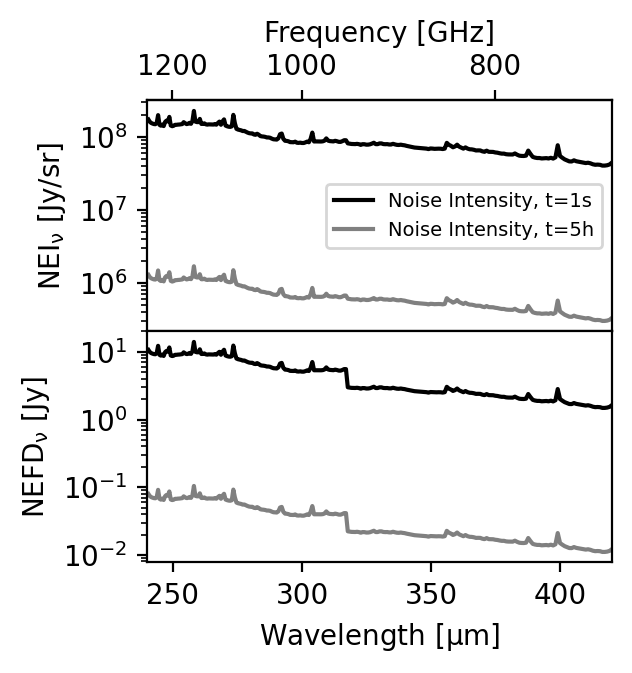

In [4]:
#compute the noise intensity out of the NEI and the survey time
t_survey = 5*3600 #s
fig, (ax, ax2) = plt.subplots(2,figsize=(3,3), dpi=200, sharex=True )  
#ax.plot(w_source, source, 'orange', label=f'SPT0418@z={z}')
ax.loglog(lambdas, noise, label='Noise Intensity, t=1s', c='k' )
ax.loglog(lambdas, noise/np.sqrt(t_survey),  label='Noise Intensity, t=5h', c='grey') 

ax2.loglog(lambdas, NEFD,  c='k' )
ax2.loglog(lambdas, NEFD/np.sqrt(t_survey), c='grey') 
ax2.set_xlabel("Wavelength [$\\rm \\mu$m]")
ax.set_ylabel("NEI$\\rm _{\\nu}$ [Jy/sr]")
ax2.set_ylabel("NEFD$\\rm _{\\nu}$ [Jy]")

ax.set_xscale("linear")
#ax.set_ylim(1e1, 1e3)
ax.set_xlim(240,420)
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('Frequency [GHz]')
ax.legend(fontsize=7, loc='center right')
fig.subplots_adjust(wspace=0, hspace=0)

In [5]:
from astropy.table import Table
df_radec = pd.read_csv("reuter_2020_data/spt_dndz_tab_a1.txt", delimiter="\t", skiprows=3)
df_fluxes = pd.read_csv("reuter_2020_data/spt_dndz_tab_d1.txt", delimiter="\t", skiprows=3)
df_propa = pd.read_csv("reuter_2020_data/spt_dndz_tab_f1.txt", delimiter="\t", skiprows=3)
df_propb = pd.read_csv("reuter_2020_data/spt_dndz_tab_f1_kappa_wd03.txt", delimiter="\t", skiprows=3)
data = Table.read('reuter_2020_data/smg_dndz_tables.fits', hdu=1)
colors = cm.plasma(np.linspace(0,1,len(data)))


Text(0.5, 0, 'Frequency [GHz]')

/tmp/ipykernel_16476/3948735471.py:25: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


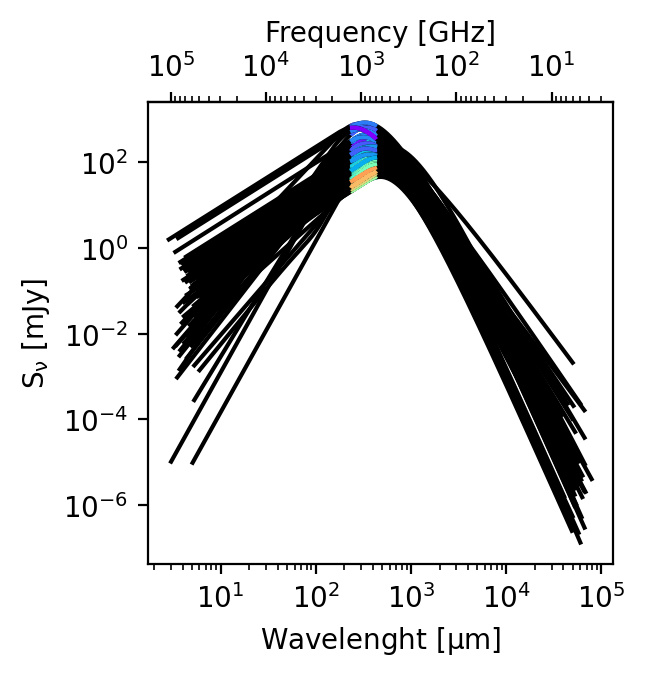

In [6]:
resample_grid =  (lambdas*u.micron)

BS = 10; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); mk = 3; lw=1
fig, ax = plt.subplots(figsize=(3, 3), dpi = 200)
patchs = []

#colors = cm.Greys(np.linspace(0,1,len(data)))
for ismg, smg in enumerate(data):

    #Redshift color coding
    zc = (smg['z_spec']-data['z_spec'].min())/(data['z_spec'].max()-data['z_spec'].min())
    c2 = cm.rainbow(zc)
    if(zc==0 or zc==1.0): patch = mpatches.Patch(color=c2, label= f"z={smg['z_spec']}"); patchs.append(patch)
    spec = Spectrum1D(spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um, flux=smg['fit_pl'][:,0]*u.mJy)
    lambda_SED = spec.spectral_axis; SED = spec.flux
    ax.loglog(lambda_SED, SED, 'k')
    
    input_spectra  = Spectrum1D( flux=SED, spectral_axis=lambda_SED)
    fluxc_resample = FluxConservingResampler()
    sed_in_tim = fluxc_resample(input_spectra, resample_grid) 
    ax.loglog(resample_grid, sed_in_tim.flux, c=c2)
    
ax.set_ylabel('$\\rm S_{\\nu}$ [mJy]'); 
ax.set_xlabel('Wavelenght [$\\rm \\mu$m]')
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('Frequency [GHz]')



/tmp/ipykernel_16476/2045830515.py:25: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


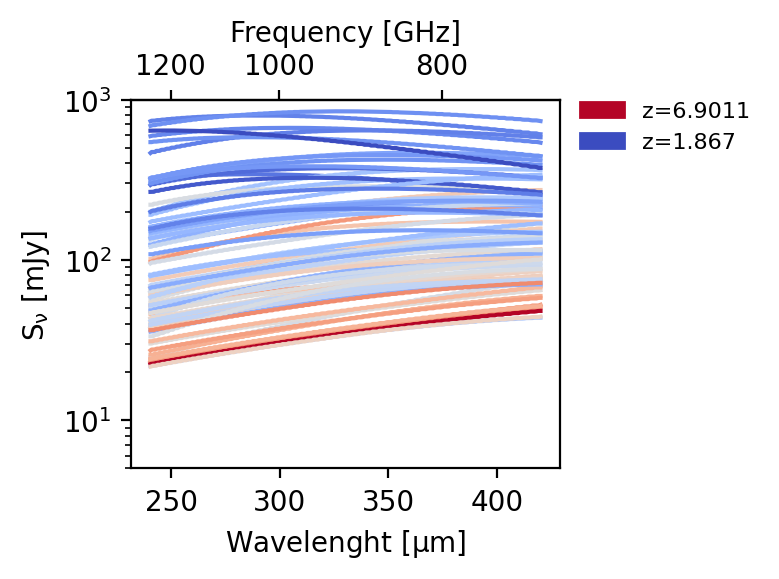

In [7]:
resample_grid =  (lambdas*u.micron)

BS = 10; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); mk = 3; lw=1
fig, ax = plt.subplots(figsize=(3, 3), dpi = 200)
patchs = []

#colors = cm.Greys(np.linspace(0,1,len(data)))
for ismg, smg in enumerate(data):

    #Redshift color coding
    zc = (smg['z_spec']-data['z_spec'].min())/(data['z_spec'].max()-data['z_spec'].min())
    c2 = cm.coolwarm(zc)
    if(zc==0 or zc==1.0): patch = mpatches.Patch(color=c2, label= f"z={smg['z_spec']}"); patchs.append(patch)
    spec = Spectrum1D(spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um, flux=smg['fit_pl'][:,0]*u.mJy)
    lambda_SED = spec.spectral_axis; SED = spec.flux
    input_spectra  = Spectrum1D( flux=SED, spectral_axis=lambda_SED)
    fluxc_resample = FluxConservingResampler()
    sed_in_tim = fluxc_resample(input_spectra, resample_grid) 
    ax.loglog(resample_grid, sed_in_tim.flux, c=c2)
    
ax.set_ylabel('$\\rm S_{\\nu}$ [mJy]'); 
ax.set_xlabel('Wavelenght [$\\rm \\mu$m]')
ax.set_yscale('log'); ax.set_xscale('linear')
ax.set_ylim(5e0, 1e3)
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('Frequency [GHz]')
#patch = mlines.Line2D([], [], color='k',  linestyle="solid", label='P.L fit, Reuter+20'); patchs.append(patch)
fig.tight_layout()
ax.legend(handles = patchs, loc = 'upper left', fontsize=8, bbox_to_anchor=(1.0, 1.05), framealpha=0)

/tmp/ipykernel_16476/1963892847.py:37: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


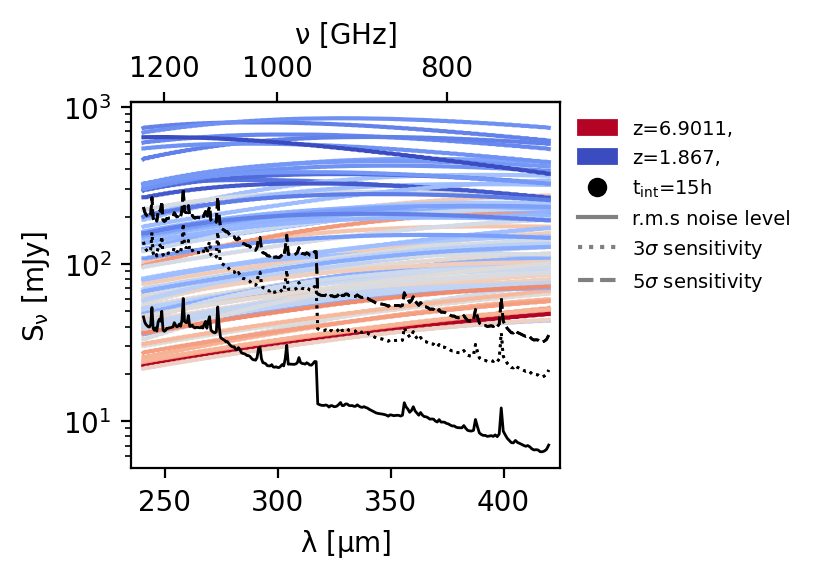

In [19]:
patchs = []
NEFD_mJy = NEFD * 1e3 #mJy

BS = 10; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); mk = 3; lw=1
fig, ax = plt.subplots(figsize=(3.0,3.0), dpi=200) 

for ismg, (smg, c) in enumerate(zip(data,colors)):

    #Redshift color coding
    zc = (smg['z_spec']-data['z_spec'].min())/(data['z_spec'].max()-data['z_spec'].min())
    c2 = cm.coolwarm(zc)
    if(zc==0 or zc==1.0): patch = mpatches.Patch(color=c2, label=f"z={smg['z_spec']}," ); patchs.append(patch)
    
    spec = Spectrum1D(spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um, flux=smg['fit_pl'][:,0]*u.mJy)
    lambda_SED = spec.spectral_axis; SED = spec.flux
    input_spectra  = Spectrum1D( flux=SED, spectral_axis=lambda_SED)
    fluxc_resample = FluxConservingResampler()
    sed_in_tim = fluxc_resample(input_spectra, resample_grid) 
    ax.loglog(resample_grid, sed_in_tim.flux, c=c2)
    
for t, c in zip((15,), ('k', 'lime', 'magenta')):
    ax.loglog(lambdas, NEFD_mJy/np.sqrt(t*3600), c=c,lw=1)
    patch = mlines.Line2D([], [],   marker='o',  color=c,linestyle="None",  label='$\\rm t_{int}$='+f'{int(t)}h'); patchs.append(patch)
    for n, ls in zip((3,5), (':', '--') ):
        ax.loglog(lambdas, n*NEFD_mJy/np.sqrt(t*3600), ls=ls, c=c,lw=1) #label=f'{n}'+'$\\rm \\sigma$ sensitivity',
        ax.loglog(lambdas, n*NEFD_mJy/np.sqrt(t*3600), ls=ls, c=c,lw=1)

patch = mlines.Line2D([], [], color='gray',  linestyle="solid",  label = 'r.m.s noise level',); patchs.append(patch)
patch = mlines.Line2D([], [], color='gray',  linestyle=":",  label = '3$\\sigma$ sensitivity',); patchs.append(patch)
patch = mlines.Line2D([], [], color='gray',  linestyle="--",  label = '5$\\sigma$ sensitivity',); patchs.append(patch)

ax.set_xlabel('$\\rm \\lambda$ $\\rm [\\mu m]$')
ax.set_xlim(235, 425)
ax.set_ylabel('$\\rm S_{\\nu}$ [mJy]')
#ax.set_ylim(1e0, 2e3)
ax.set_xscale('linear')
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('$\\rm \\nu$ [GHz]')
fig.tight_layout()
ax.legend(handles = patchs,fontsize=7, bbox_to_anchor=(1,1), framealpha=0)

In [9]:
FIR_lines_list = [r'SIII 33$\rm \mu m$', r'SiII 35$\rm \mu m$', r'OIII 52$\rm \mu m$', 
                   r'NIII 57$\rm \mu m$', r'OI 63$\rm \mu m$', r'OIII 88$\rm \mu m$', r'NII 122$\rm \mu m$',
                   r'OI 145$\rm \mu m$'] 
FIR_lines_nu =   [8954.37449223,  8609.77765652,  5786.382127  , 5230.15453594,  4746.55569981,  3392.85262562,  2459.33107465, 2060.4292646]

# Calculate the differences between adjacent bin centers
diffs = (np.diff(lambdas)*u.um / 2.0)
# Calculate the edges
bin_edges = np.zeros(len(lambdas) + 1)*u.um
bin_edges[1:-1] = (lambdas*u.um)[:-1]+ diffs
bin_edges[0] =    (lambdas*u.um)[0]- diffs[0]
bin_edges[-1] =   (lambdas*u.um)[-1]+ diffs[-1]

In [27]:
for ismg, smg in enumerate(data):
    N=5

    BS = 7; plt.rc('font', size=BS); plt.rc('axes', titlesize=BS); plt.rc('axes', labelsize=BS); mk = 3; lw=1
    fig, ax = plt.subplots(1,1,figsize=(3,3), dpi=200)  
    spec = Spectrum1D(spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um, flux=smg['fit_pl'][:,0]*u.mJy)
    lambda_SED = spec.spectral_axis; SED = spec.flux
    input_spectra  = Spectrum1D( flux=SED, spectral_axis=lambda_SED)
    fluxc_resample = FluxConservingResampler()
    sed_in_tim = fluxc_resample(input_spectra, resample_grid) 
    ax.loglog(resample_grid, sed_in_tim.flux, c='k', lw=1)
    
    N = 5
    t_int = ((N * NEFD_mJy / sed_in_tim.flux)**2)
    
    for j, (J, rest_freq, c) in enumerate(zip(FIR_lines_list, FIR_lines_nu, cm.Reds(np.linspace(0,1,len(FIR_lines_list))) )):
        w = cst.c / (rest_freq*1e9) *1e6
        w_obs = w * (1+smg['z_spec'])
        bin_index = np.digitize(w_obs, bin_edges.value) - 1  # Subtract 1 for zero-based index#
            
        if(bin_index >= 0 and bin_index <= len(lambdas)-1): 
            closest_bin_center_index = np.argmin(np.abs(lambdas - w_obs))
            T = (t_int[closest_bin_center_index].value/60)
            ax.loglog(lambdas, NEFD_mJy/np.sqrt(t_int[closest_bin_center_index].value), c=c,  label=f'A detection of {J} at {N}'+'$\\rm \\sigma$ \n needs t='+f'{T:.2f}min')
            ax.loglog((w_obs, w_obs),(1e1, 1e3), c=c)
    
    ax.set_xlabel("Wavelength [$\\rm \\mu$m]")
    ax.set_ylabel("S$\\rm \\nu$ [mJy]")
    ax.set_xlim(235, 425)
    ax.set_ylim(1e0, 1e3)
    ax.set_xscale('linear')
    def w_to_f(x): return cst.c/(x*1e-6)/1e9
    secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
    secax.set_xlabel('Frequency [GHz]')
    ax.set_xscale('linear')
    fig.tight_layout()
    ax.legend(title=f'{smg["spt_id"]} at z=z{smg["z_spec"]}', fontsize=4, loc='lower left', framealpha=0)
    fig.savefig(f'figures/{ismg}_{smg["spt_id"]}_{N}sigma.png')
    plt.close()
    

/tmp/ipykernel_16476/1545533109.py:32: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


In [30]:
from scientific_notation import print_scientific_notation

FIR_lines_list = [ r'OIII 52$\rm \mu m$', 
                   r'NIII 57$\rm \mu m$', r'OI 63$\rm \mu m$', r'OIII 88$\rm \mu m$', r'NII 122$\rm \mu m$',
                   r'OI 145$\rm \mu m$'] 
FIR_lines_nu =   [ 5786.382127  , 5230.15453594,  4746.55569981,  3392.85262562,  2459.33107465, 2060.4292646]
data = sorted(data, key=lambda x: x['z_spec'])

for N in (5,):
    
    d = 'detect'
    print(r'\begin{table}[h!]')
    print('\centering')
    print("\caption{Table needed integration time to "+f"{d}"+" lines at "+f"{N}"+r"$\rm \sigma$}")
    print(r'\resizebox{\textwidth}{!}{')
    print(r'\begin{tabular}{p{0.2\linewidth}c|c|c|c|c|c|c|c|c}')
    print(r'\hline')
    print(r'\hline')
    print(r'\noalign{\smallskip}')
    L = 'SPT ID & z spec.'
    for J in FIR_lines_list:
            L+= ' & '+J
    print(L+r'\\')
    print(r'\hline')
    print(r'\hline')
    
    for ismg, (smg,c) in enumerate(zip(data,colors)):
        L = smg['spt_id']+' & '+f'{smg["z_spec"]}' 

        input_spectra  = Spectrum1D(flux=smg['fit_pl'][:,0]*u.mJy, 
                                    spectral_axis=(smg['um_obs_pl']*(1+smg['z_spec']))[:,0]*u.um)
        fluxc_resample = FluxConservingResampler()
        sed_in_tim = fluxc_resample(input_spectra, lambdas*u.um)
        #ax.loglog(sed_in_tim.spectal_axis, sed_in_tim.flux, c=c)
        t = ((N * NEFD_mJy/ sed_in_tim.flux)**2)

        for j, (J, rest_freq) in enumerate(zip(FIR_lines_list, FIR_lines_nu)):
            w = cst.c / (rest_freq*1e9) * 1e6
            w_obs = w * (1+smg['z_spec'])
            bin_index = np.digitize(w_obs, bin_edges.value) - 1  # Subtract 1 for zero-based index#
            
            if(bin_index >= 0 and bin_index <= len(lambdas)-1): 
                closest_bin_center_index = np.argmin(np.abs(lambdas - w_obs))
                T = print_scientific_notation((t[closest_bin_center_index].value/3600))
                L += f' & {T}'
            else: L += ' & '
            
        print(L + r'\\')
    print(r'\hline')
    print(r'\hline')
    print(r'\end{tabular}}')
    print(r'\end{table}')
    print('')
    print('')
    print('')

\begin{table}[h!]
\centering
\caption{Table needed integration time to detect lines at 5$\rm \sigma$}
\resizebox{\textwidth}{!}{
\begin{tabular}{p{0.2\linewidth}c|c|c|c|c|c|c|c|c}
\hline
\hline
\noalign{\smallskip}
SPT ID & z spec. & OIII 52$\rm \mu m$ & NIII 57$\rm \mu m$ & OI 63$\rm \mu m$ & OIII 88$\rm \mu m$ & NII 122$\rm \mu m$ & OI 145$\rm \mu m$\\
\hline
\hline
SPT2354-58 & 1.867 &  &  &  & \textbf{1.4h} & \textbf{0.11h} & \textbf{0.63h}\\
SPT0611-55 & 2.026 &  &  &  & \textbf{7.0h} & \textbf{0.26h} & \\
SPT0512-59 & 2.2334 &  &  &  & \textbf{2.1h} & \textbf{0.12h} & \\
SPT0002-52 & 2.351 &  &  &  & \textbf{1.6h} & \textbf{0.16h} & \\
SPT2031-51 & 2.4521 &  &  &  & \textbf{2.8h} &  & \\
SPT0604-64 & 2.4807 &  &  &  & \textbf{0.30h} &  & \\
SPT2311-45 & 2.5073 &  &  &  & \textbf{5.0h} &  & \\
SPT0125-47 & 2.5149 &  &  &  & \textbf{0.20h} &  & \\
SPT0551-48 & 2.5833 &  &  &  & \textbf{0.29h} &  & \\
SPT0402-45 & 2.6833 &  &  &  & \textbf{0.48h} &  & \\
SPT2332-53 & 2.7256 &  &  & 